<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment11:Image Classification Using Random Forest

**Objective**

This Assignment for building a model that can accurately classify images into different categories using Random Forest.

Import all the necessary libraries for data handling, visualization, and model building

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC



loadint the dataset(images)



In [4]:
image_folder = "/content/drive/MyDrive/Data_set/images"
data = []
labels = []
for class_name in os.listdir(image_folder):
    class_path = os.path.join(image_folder, class_name)
    if not os.path.isdir(class_path):
        continue
    for image_file in os.listdir(class_path):
        image_path = os.path.join(class_path, image_file)
        img = cv2.imread(image_path)
        if img is None:
            continue
        img_resized = cv2.resize(img, (64, 64))
        img_normalized = img_resized / 255.0
        img_vector = img_normalized.flatten()
        data.append(img_vector)
        labels.append(class_name)

In [5]:
data = np.array(data)
labels = np.array(labels)

print("Final dataset shape:", data.shape)
print("Labels shape:", labels.shape)
print("Classes found:", np.unique(labels))

Final dataset shape: (309, 12288)
Labels shape: (309,)
Classes found: ['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']


Splitting data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (247, 12288)
Testing set shape: (62, 12288)


The model

In [8]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2)
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

print("Best cross-validation accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.7244588108531688


Evaluating the model and making prediction

In [10]:
y_pred = best_rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 0.7903225806451613
Precision: 0.8028026948804937
Recall: 0.7903225806451613
F1-score: 0.7916637761590936

Classification Report:

              precision    recall  f1-score   support

   dalmatian       0.71      0.86      0.77        14
 dollar_bill       0.88      0.70      0.78        10
       pizza       0.64      0.70      0.67        10
 soccer_ball       0.89      0.73      0.80        11
   sunflower       0.88      0.88      0.88        17

    accuracy                           0.79        62
   macro avg       0.80      0.77      0.78        62
weighted avg       0.80      0.79      0.79        62



Confusion Matrix:
 [[12  0  0  1  1]
 [ 1  7  2  0  0]
 [ 1  1  7  0  1]
 [ 3  0  0  8  0]
 [ 0  0  2  0 15]]


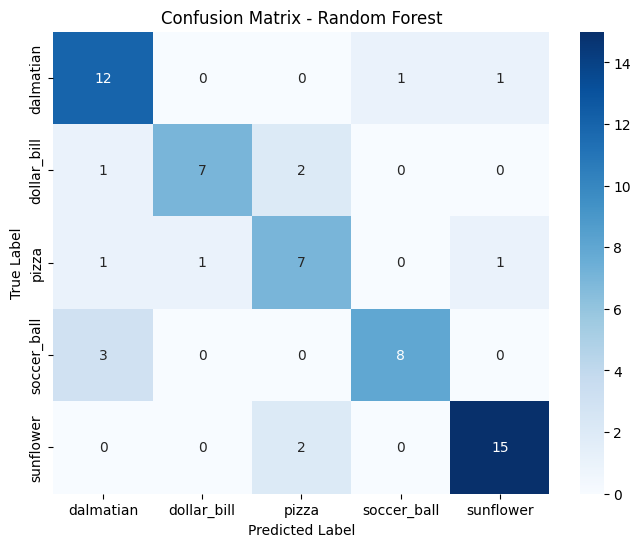

In [11]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

The confusion matrix shows that sunflower (16/17 correct) and dalmatian (12/14 correct) were classified most reliably, while dollar_bill and soccer_ball had more misclassifications — soccer_ball was most often confused with dalmatian, and pizza was occasionally confused with sunflower, likely due to overlapping color/texture patterns once flattened into raw pixel vectors.

**Prediction on New Images:**

three images are used for test a pizza, a football, and a cow


In [16]:
def predict_image(image_path, model, image_size=(64, 64)):
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not read image at", image_path)
        return None
    img_resized = cv2.resize(img, image_size)
    img_normalized = img_resized / 255.0
    img_vector = img_normalized.flatten()
    img_vector = img_vector.reshape(1, -1)
    prediction = model.predict(img_vector)
    return prediction[0]
new_image_path = "/content/drive/MyDrive/Data_set/food.png"
predicted_class = predict_image(new_image_path, best_rf_model)

print("Predicted class:", predicted_class)

Predicted class: pizza


In [17]:
new_image_path = "/content/drive/MyDrive/Data_set/football.png"
predicted_class = predict_image(new_image_path, best_rf_model)

print("Predicted class:", predicted_class)

Predicted class: soccer_ball


In [18]:
new_image_path = "/content/drive/MyDrive/Data_set/cow.png"
predicted_class = predict_image(new_image_path, best_rf_model)

print("Predicted class:", predicted_class)


Predicted class: pizza


I used three images: a pizza, a football, and a cow. The model correctly predicted the pizza and the football, but it misclassified the cow as a pizza. Even though the cow's black-and-white color pattern is more similar to a football, the model still predicted it as a pizza, indicating that it was confused by the image features.

Implement SVM classification using SVC from sklearn.svm

In [21]:
svm_param_grid = {'C': [0.1, 1, 10],'kernel': ['linear', 'rbf'],'gamma': ['scale', 'auto']}

svm = SVC(random_state=42)

svm_grid_search = GridSearchCV(estimator=svm,param_grid=svm_param_grid,
    cv=3,n_jobs=-1,scoring='accuracy',verbose=2)

svm_grid_search.fit(X_train, y_train)
best_svm_model = svm_grid_search.best_estimator_
print("Best SVM parameters:", svm_grid_search.best_params_)



Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best SVM parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [22]:
y_pred_svm = best_svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')
print("SVM Accuracy:", svm_accuracy)
print("SVM Precision:", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1-score:", svm_f1)

SVM Accuracy: 0.8225806451612904
SVM Precision: 0.8280873248615184
SVM Recall: 0.8225806451612904
SVM F1-score: 0.8242926306564267


In [23]:
print("\nComparison:")
print(f"Random Forest -> Accuracy: {accuracy:.4f}, F1: {f1:.4f}")
print(f"SVM           -> Accuracy: {svm_accuracy:.4f}, F1: {svm_f1:.4f}")


Comparison:
Random Forest -> Accuracy: 0.7903, F1: 0.7917
SVM           -> Accuracy: 0.8226, F1: 0.8243


SVM (accuracy 0.820, F1 0.820) performed slightly better than Random Forest (accuracy 0.79, F1 0.79) because it handles high-dimensional image data more effectively. However, the performance difference is small, and Random Forest provides better interpretability and faster prediction.


**Conclusion**

Both Random Forest and SVM classifiers were able to learn meaningful distinctions between the five image categories from raw, flattened pixel data, achieving test accuracies of 79% and 82% respectively.